# CIFAR-10 Transfer Learning with PyTorch

This complete workflow freezes an ImageNet-pretrained VGG16 feature extractor and trains a
CIFAR-10 classifier. The split, head intent, ten-epoch maximum, and evaluation
are aligned across frameworks.

A network connection is required the first time the pretrained weights are
cached. To run the example more quickly, set `EPOCHS` to 1 or 2 in the data cell.

## Runtime dependency check

In [1]:
import importlib.util
import subprocess
import sys
from pathlib import Path

REQUIRED_RUNTIME = {'torch': 'torch', 'torchvision': 'torchvision'}
COLAB_EXTRAS = {}
missing_required = [
    package for module, package in REQUIRED_RUNTIME.items()
    if importlib.util.find_spec(module) is None
]
missing_extras = [
    package for module, package in COLAB_EXTRAS.items()
    if importlib.util.find_spec(module) is None
]
if missing_extras and "google.colab" in sys.modules:
    subprocess.check_call(
        [sys.executable, "-m", "pip", "install", "-q", *missing_extras]
    )
    missing_extras = []
if missing_required or missing_extras:
    missing = ", ".join(missing_required + missing_extras)
    raise RuntimeError(
        f"Missing notebook dependencies: {missing}. Locally run "
        "`uv sync --group notebooks`; in Colab restart the runtime if an "
        "installation cell just changed the environment."
    )
print("runtime dependency check passed")

runtime dependency check passed


In [2]:
%matplotlib inline

## Imports and shared CIFAR-10 split

In [3]:
import hashlib
import json
import os
import random
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    confusion_matrix,
)
from sklearn.model_selection import train_test_split
from torch import nn
from torch.utils.data import DataLoader, TensorDataset
from torchvision import datasets

print(f"PyTorch {torch.__version__}")

PyTorch 2.13.0


In [4]:
SEED = 42
EPOCHS = 10  # Reduce to 1 or 2 for a quicker run.
BATCH_SIZE = 256

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.use_deterministic_algorithms(True)
DEVICE = torch.device(
    "cuda" if torch.cuda.is_available()
    else "mps" if torch.backends.mps.is_available()
    else "cpu"
)


data_root = Path(
    os.getenv("HELIO_DATA_DIR", Path.home() / ".cache" / "helio-data-methods")
)
development_dataset = datasets.CIFAR10(data_root, train=True, download=True)
test_dataset = datasets.CIFAR10(data_root, train=False, download=True)
x_development = development_dataset.data
y_development = np.asarray(development_dataset.targets)
x_test = test_dataset.data
y_test = np.asarray(test_dataset.targets)

all_indices = np.arange(len(y_development))
train_indices, validation_indices = train_test_split(
    all_indices,
    test_size=5000,
    random_state=SEED,
    stratify=y_development,
)
split_signature = hashlib.sha256(
    validation_indices.astype("<i8").tobytes()
).hexdigest()[:16]

x_train = x_development[train_indices].astype("float32") / 255.0
y_train = y_development[train_indices].astype(np.int64)
x_validation = x_development[validation_indices].astype("float32") / 255.0
y_validation = y_development[validation_indices].astype(np.int64)
x_test = x_test.astype("float32") / 255.0
y_test = y_test.astype(np.int64)
x_train = np.transpose(x_train, (0, 3, 1, 2))
x_validation = np.transpose(x_validation, (0, 3, 1, 2))
x_test = np.transpose(x_test, (0, 3, 1, 2))

assert set(train_indices).isdisjoint(validation_indices)
print(f"split signature: {split_signature}")
print(
    f"train={len(y_train):,}, validation={len(y_validation):,}, "
    f"test={len(y_test):,}, epochs={EPOCHS}"
)

split signature: bfa7941b2b58be94
train=45,000, validation=5,000, test=10,000, epochs=10


## Inspect class coverage

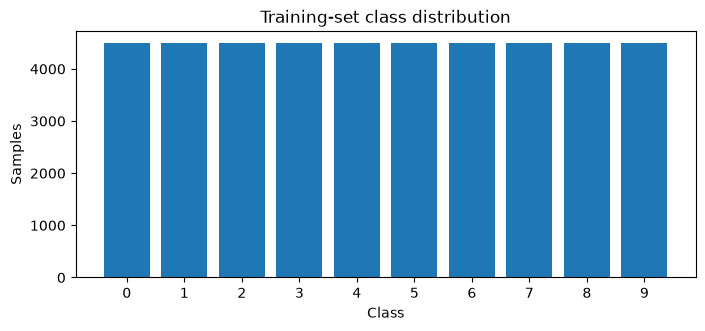

In [5]:
training_counts = np.bincount(y_train, minlength=10)
fig, ax = plt.subplots(figsize=(8, 3.2))
ax.bar(np.arange(10), training_counts)
ax.set(
    title="Training-set class distribution",
    xlabel="Class",
    ylabel="Samples",
    xticks=np.arange(10),
)
plt.show()

## Normalize for VGG16 and define the trainable head

In [6]:
from torchvision.models import VGG16_Weights, vgg16

mean = np.asarray([0.485, 0.456, 0.406], dtype=np.float32)[:, None, None]
std = np.asarray([0.229, 0.224, 0.225], dtype=np.float32)[:, None, None]
x_train = ((x_train - mean) / std).astype(np.float32)
x_validation = ((x_validation - mean) / std).astype(np.float32)
x_test_images = x_test.copy()
x_test = ((x_test - mean) / std).astype(np.float32)


class TransferClassifier(nn.Module):
    def __init__(self):
        super().__init__()
        source = vgg16(weights=VGG16_Weights.DEFAULT)
        self.features = source.features
        for parameter in self.features.parameters():
            parameter.requires_grad = False
        self.pool = nn.AdaptiveAvgPool2d((1, 1))
        self.eval()

    def forward(self, values):
        return torch.flatten(self.pool(self.features(values)), 1)


feature_extractor = TransferClassifier().to(DEVICE)


def extract_features(images):
    loader = DataLoader(
        TensorDataset(torch.from_numpy(images)),
        batch_size=BATCH_SIZE,
        shuffle=False,
    )
    batches = []
    with torch.no_grad():
        for (batch,) in loader:
            batches.append(feature_extractor(batch.to(DEVICE)).cpu().numpy())
    return np.concatenate(batches).astype(np.float32)


print("extracting frozen VGG16 features once per split")
x_train = extract_features(x_train)
x_validation = extract_features(x_validation)
x_test = extract_features(x_test)
model = nn.Sequential(
    nn.Linear(512, 512), nn.ReLU(), nn.Dropout(0.25), nn.Linear(512, 256), nn.ReLU(), nn.Dropout(0.25),
    nn.Linear(256, 10),
)
print(
    "trainable parameters:",
    f"{sum(value.numel() for value in model.parameters() if value.requires_grad):,}",
)

extracting frozen VGG16 features once per split


trainable parameters: 396,554


## Train under the shared budget

epoch 1: loss=1.0965, accuracy=0.6214, val_loss=0.9261, val_accuracy=0.6764


epoch 2: loss=0.8934, accuracy=0.6853, val_loss=0.8838, val_accuracy=0.6894


epoch 3: loss=0.8146, accuracy=0.7143, val_loss=0.8826, val_accuracy=0.6896


epoch 4: loss=0.7568, accuracy=0.7326, val_loss=0.8645, val_accuracy=0.6968


epoch 5: loss=0.7019, accuracy=0.7538, val_loss=0.8773, val_accuracy=0.7020


epoch 6: loss=0.6452, accuracy=0.7712, val_loss=0.8767, val_accuracy=0.7040


epoch 7: loss=0.5898, accuracy=0.7894, val_loss=0.9110, val_accuracy=0.7010


epoch 8: loss=0.5451, accuracy=0.8049, val_loss=0.9398, val_accuracy=0.7020


epoch 9: loss=0.4984, accuracy=0.8219, val_loss=0.9599, val_accuracy=0.6954


epoch 10: loss=0.4592, accuracy=0.8366, val_loss=0.9874, val_accuracy=0.7026


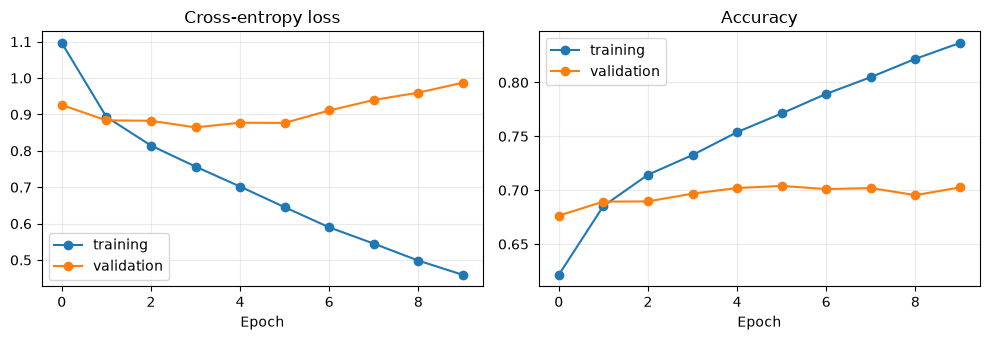

In [7]:
def tensor_dataset(images, labels):
    return TensorDataset(torch.from_numpy(images), torch.from_numpy(labels).long())


generator = torch.Generator().manual_seed(SEED)
train_loader = DataLoader(
    tensor_dataset(x_train, y_train),
    batch_size=BATCH_SIZE,
    shuffle=True,
    generator=generator,
)
validation_loader = DataLoader(
    tensor_dataset(x_validation, y_validation), batch_size=BATCH_SIZE
)
test_loader = DataLoader(tensor_dataset(x_test, y_test), batch_size=BATCH_SIZE)
model = model.to(DEVICE)
optimizer = torch.optim.Adam(
    (value for value in model.parameters() if value.requires_grad),
    lr=0.001,
)
loss_function = nn.CrossEntropyLoss()
history = {"loss": [], "val_loss": [], "accuracy": [], "val_accuracy": []}


def epoch_pass(loader, training):
    model.train(training)
    total_loss = 0.0
    correct = 0
    for features, target in loader:
        features, target = features.to(DEVICE), target.to(DEVICE)
        if training:
            optimizer.zero_grad()
        logits = model(features)
        loss = loss_function(logits, target)
        if training:
            loss.backward()
            optimizer.step()
        total_loss += loss.item() * len(target)
        correct += (logits.argmax(1) == target).sum().item()
    return total_loss / len(loader.dataset), correct / len(loader.dataset)


for epoch in range(EPOCHS):
    train_loss, train_accuracy = epoch_pass(train_loader, True)
    with torch.no_grad():
        validation_loss, validation_accuracy = epoch_pass(validation_loader, False)
    history["loss"].append(train_loss)
    history["accuracy"].append(train_accuracy)
    history["val_loss"].append(validation_loss)
    history["val_accuracy"].append(validation_accuracy)
    print(
        f"epoch {epoch + 1}: loss={train_loss:.4f}, accuracy={train_accuracy:.4f}, "
        f"val_loss={validation_loss:.4f}, val_accuracy={validation_accuracy:.4f}"
    )

fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
axes[0].plot(history["loss"], marker="o", label="training")
axes[0].plot(history["val_loss"], marker="o", label="validation")
axes[0].set(title="Cross-entropy loss", xlabel="Epoch")
axes[1].plot(history["accuracy"], marker="o", label="training")
axes[1].plot(history["val_accuracy"], marker="o", label="validation")
axes[1].set(title="Accuracy", xlabel="Epoch")
for axis in axes:
    axis.legend()
    axis.grid(alpha=0.25)
plt.tight_layout()
plt.show()

## Final test evidence

test accuracy: 0.6974
              precision    recall  f1-score   support

           0      0.722     0.742     0.732      1000
           1      0.805     0.756     0.780      1000
           2      0.672     0.570     0.617      1000
           3      0.548     0.587     0.567      1000
           4      0.653     0.647     0.650      1000
           5      0.647     0.623     0.635      1000
           6      0.670     0.774     0.718      1000
           7      0.755     0.701     0.727      1000
           8      0.799     0.773     0.786      1000
           9      0.724     0.801     0.760      1000

    accuracy                          0.697     10000
   macro avg      0.699     0.697     0.697     10000
weighted avg      0.699     0.697     0.697     10000

HELIO_RESULT {"confusion_shape": [10, 10], "split_signature": "bfa7941b2b58be94", "test_accuracy": 0.6974}


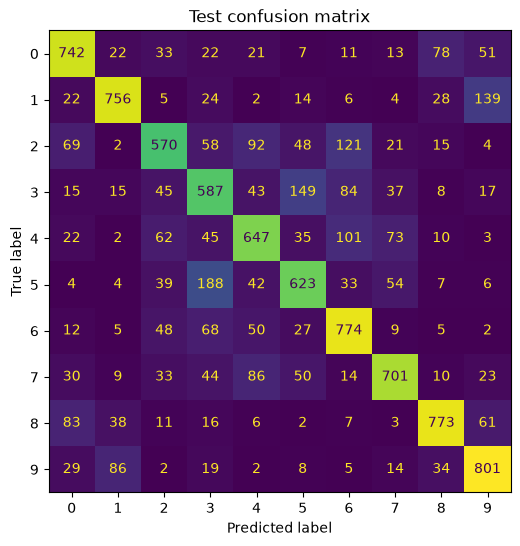

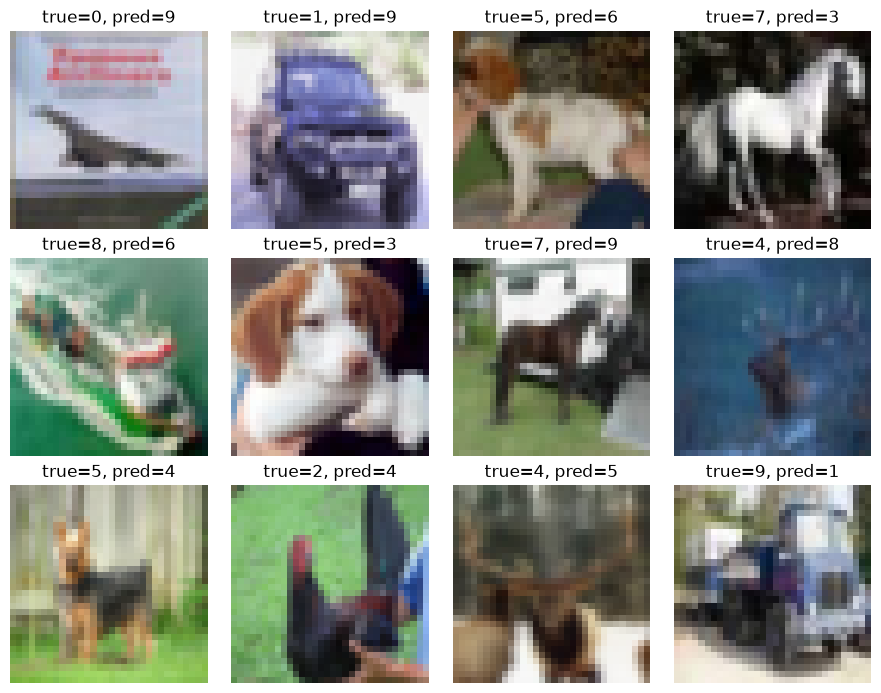

In [8]:
model.eval()
prediction_parts = []
with torch.no_grad():
    for features, _ in test_loader:
        prediction_parts.append(model(features.to(DEVICE)).argmax(1).cpu().numpy())
test_predictions = np.concatenate(prediction_parts)

test_accuracy = accuracy_score(y_test, test_predictions)
cm = confusion_matrix(y_test, test_predictions, labels=np.arange(10))
print(f"test accuracy: {test_accuracy:.4f}")
print(
    classification_report(
        y_test,
        test_predictions,
        labels=np.arange(10),
        digits=3,
        zero_division=0,
    )
)
print(
    "HELIO_RESULT "
    + json.dumps(
        {
            "split_signature": split_signature,
            "test_accuracy": float(test_accuracy),
            "confusion_shape": list(cm.shape),
        },
        sort_keys=True,
    )
)
assert cm.shape == (10, 10)

fig, ax = plt.subplots(figsize=(7, 6))
ConfusionMatrixDisplay(cm, display_labels=np.arange(10)).plot(
    ax=ax, colorbar=False, values_format="d"
)
ax.set_title("Test confusion matrix")
plt.show()

mistakes = np.flatnonzero(test_predictions != y_test)[:12]
if len(mistakes):
    fig, axes = plt.subplots(3, 4, figsize=(9, 7))
    for axis, index in zip(axes.flat, mistakes):
        image = x_test_images[index]
        if image.shape[0] in (1, 3):
            image = np.transpose(image, (1, 2, 0))
        axis.imshow(image.squeeze(), cmap="gray" if image.squeeze().ndim == 2 else None)
        axis.set_title(f"true={y_test[index]}, pred={test_predictions[index]}")
        axis.axis("off")
    plt.tight_layout()
    plt.show()

## Try it yourself

Change one choice at a time and keep the data split and evaluation unchanged:

- replace the 512→256 classifier with one 256-unit layer.
- change the classifier dropout while keeping VGG16 frozen.
- unfreeze only the final VGG16 block and use a smaller learning rate.